# EEN1072 - Convolutional Neural Network for Object Detection & Depth Estimation

## Dataset: KITTI Vision Benchmark Suite
This notebook implements a CNN from scratch to detect objects (cars, pedestrians, cyclists)
and estimate their depth from dashboard camera images.

In [4]:
!git config --global user.email "victorakins02@hotmail.com"
!git config --global user.name "victorakins02"

!git add .
!git commit -m "Start of Project"
!git branch -M main
!git push -u origin main

[main (root-commit) 0566cba] Start of Project
 21 files changed, 51059 insertions(+)
 create mode 100644 .config/.last_opt_in_prompt.yaml
 create mode 100644 .config/.last_survey_prompt.yaml
 create mode 100644 .config/.last_update_check.json
 create mode 100644 .config/active_config
 create mode 100644 .config/config_sentinel
 create mode 100644 .config/configurations/config_default
 create mode 100644 .config/default_configs.db
 create mode 100644 .config/gce
 create mode 100644 .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
 create mode 100644 .config/logs/2026.01.16/14.23.31.981136.log
 create mode 100644 .config/logs/2026.01.16/14.24.03.314209.log
 create mode 100644 .config/logs/2026.01.16/14.24.13.071214.log
 create mode 100644 .config/logs/2026.01.16/14.24.18.954466.log
 create mode 100644 .config/logs/2026.01.16/14.24.28.646070.log
 create mode 100644 .config/logs/2026.01.16/14.24.29.392089.log
 create mode 100755 sample_data/README.md
 create mode 1007

In [6]:
# Install required libraries
!pip install matplotlib numpy torch torchvision -q

# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Importing Dataset

In [11]:
# Download KITTI dataset from public URL (no login required)
!wget -q https://github.com/ultralytics/assets/releases/download/v0.0.0/kitti.zip

# Unzip it
!unzip -q kitti.zip

# Check what we got
for folder in ['images', 'labels']:
    print(f"\n{folder}/")
    for subfolder in os.listdir(folder):
        count = len(os.listdir(f'{folder}/{subfolder}'))
        print(f"  {subfolder}: {count} files")

replace images/train/003384.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
A
A

images/
  train: 5985 files
  val: 1496 files

labels/
  train: 5985 files
  val: 1496 files


Checking the top of dataset

In [16]:
files = os.listdir('images/train')
print(files[:5])

['004034.png', '001551.png', '001022.png', '002364.png', '006090.png']


Used PIL (Pillow) to open images

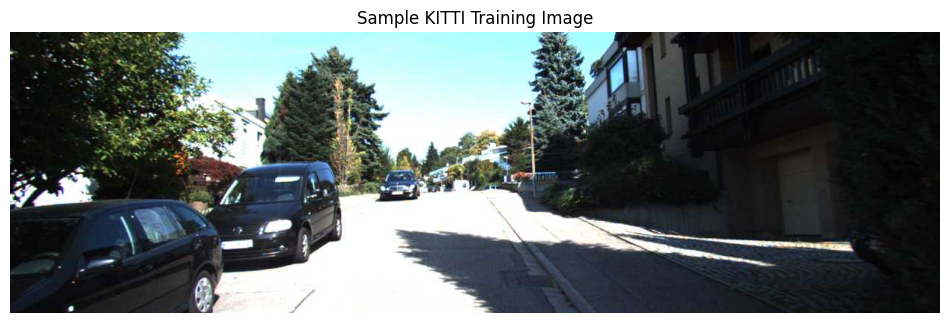

Image size: (1242, 375)
Image mode: RGB


In [17]:
from PIL import Image

# Pick a sample image
img_path = 'images/train/004034.png'
img = Image.open(img_path)

# Display it
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.title('Sample KITTI Training Image')
plt.axis('off')
plt.show()

# Print basic info about the image
print(f"Image size: {img.size}")
print(f"Image mode: {img.mode}")

In [26]:
# Remove images and labels folders from git tracking
!git rm -r --cached images/
!git rm -r --cached labels/
!git rm -r --cached .config/
!git rm -r --cached sample_data/

# Commit the removal
!git commit -m "Remove data folders from tracking"

# Force push
!git push origin main --force

Streaming output truncated to the last 5000 lines.
 delete mode 100644 labels/train/003118.txt
 delete mode 100644 labels/train/003119.txt
 delete mode 100644 labels/train/003120.txt
 delete mode 100644 labels/train/003121.txt
 delete mode 100644 labels/train/003122.txt
 delete mode 100644 labels/train/003123.txt
 delete mode 100644 labels/train/003124.txt
 delete mode 100644 labels/train/003125.txt
 delete mode 100644 labels/train/003126.txt
 delete mode 100644 labels/train/003127.txt
 delete mode 100644 labels/train/003128.txt
 delete mode 100644 labels/train/003129.txt
 delete mode 100644 labels/train/003130.txt
 delete mode 100644 labels/train/003131.txt
 delete mode 100644 labels/train/003132.txt
 delete mode 100644 labels/train/003133.txt
 delete mode 100644 labels/train/003135.txt
 delete mode 100644 labels/train/003136.txt
 delete mode 100644 labels/train/003137.txt
 delete mode 100644 labels/train/003138.txt
 delete mode 100644 labels/train/003139.txt
 delete mode 100644 label

In [29]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('/content/drive/MyDrive/DAML_CNN.ipynb', '/content/DAML_CNN.ipynb')

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/DAML_CNN.ipynb'